# Patient-Level Data Split and Missingness Analysis

This notebook:

1. Loads the ICU mortality cohort created in Notebook 2.
2. Validates identifiers and the binary target.
3. Examines missing data.
4. Splits the data into training, validation, and test sets at the **patient level**.
5. Verifies that no patient appears in more than one split.
6. Saves raw, unprocessed datasets.

Preprocessing is intentionally **not** performed here. Imputation, scaling, and one-hot encoding will later be fitted on the training data only through a scikit-learn pipeline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/icu_mortality_cohort_demo.csv")
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results/tables")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input file:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Input file: ..\data\processed\icu_mortality_cohort_demo.csv
File exists: True


## 1. Load the cohort

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Run Notebook 2 first to create the cohort file."
    )

modeling_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", modeling_df.shape)
modeling_df.head()

Dataset shape: (128, 15)


,subject_id,hadm_id,stay_id,intime,prediction_time,outtime,gender,anchor_age,admission_type,admission_location,insurance,marital_status,race,first_careunit,hospital_expire_flag
0,10023771,20044587,33177122,2113-08-25 09:32:41,2113-08-26 09:32:41,2113-08-27 16:27:53,M,70,ELECTIVE,PHYSICIAN REFERRAL,Medicare,MARRIED,WHITE,Cardiac Vascular Intensive Care Unit (CVICU),0
1,10005909,20199380,36496303,2144-10-29 23:09:03,2144-10-30 23:09:03,2144-11-02 15:24:29,F,40,OBSERVATION ADMIT,EMERGENCY ROOM,Other,MARRIED,WHITE,Cardiac Vascular Intensive Care Unit (CVICU),0
2,10003400,20214994,32128372,2137-02-25 23:37:19,2137-02-26 23:37:19,2137-03-10 21:29:36,F,72,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),0
3,10008454,20291550,31959184,2110-11-30 17:11:36,2110-12-01 17:11:36,2110-12-05 16:48:24,F,26,EW EMER.,EMERGENCY ROOM,Other,SINGLE,WHITE,Trauma SICU (TSICU),0
4,10019385,20297618,39268883,2180-02-21 08:34:06,2180-02-22 08:34:06,2180-02-22 16:05:14,M,44,URGENT,TRANSFER FROM HOSPITAL,Other,MARRIED,WHITE,Cardiac Vascular Intensive Care Unit (CVICU),0


## 2. Validate required columns and keys

In [3]:
required_columns = [
    "subject_id",
    "hadm_id",
    "stay_id",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "marital_status",
    "race",
    "first_careunit",
    "hospital_expire_flag",
]

missing_required_columns = [
    column for column in required_columns
    if column not in modeling_df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

print("All required columns are present.")

All required columns are present.


In [4]:
assert modeling_df["subject_id"].notna().all(), "Missing subject_id values found."
assert modeling_df["hadm_id"].notna().all(), "Missing hadm_id values found."
assert modeling_df["stay_id"].notna().all(), "Missing stay_id values found."

assert modeling_df["hadm_id"].is_unique, (
    "hadm_id is not unique. Notebook 2 should retain only one ICU stay "
    "per hospital admission."
)

assert modeling_df["stay_id"].is_unique, (
    "stay_id is not unique."
)

assert modeling_df["hospital_expire_flag"].notna().all(), (
    "Missing target values found."
)

assert modeling_df["hospital_expire_flag"].isin([0, 1]).all(), (
    "hospital_expire_flag must contain only 0 and 1."
)

print("Cohort validation passed.")

Cohort validation passed.


In [5]:
cohort_summary = pd.Series(
    {
        "rows": len(modeling_df),
        "unique_patients": modeling_df["subject_id"].nunique(),
        "unique_admissions": modeling_df["hadm_id"].nunique(),
        "unique_icu_stays": modeling_df["stay_id"].nunique(),
        "deaths": int(modeling_df["hospital_expire_flag"].sum()),
        "mortality_rate": modeling_df["hospital_expire_flag"].mean(),
    },
    name="value",
)

cohort_summary

rows                 128.000000
unique_patients      100.000000
unique_admissions    128.000000
unique_icu_stays     128.000000
deaths                15.000000
mortality_rate         0.117188
Name: value, dtype: float64

## 3. Review data types and descriptive statistics

In [6]:
modeling_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            128 non-null    int64
 1   hadm_id               128 non-null    int64
 2   stay_id               128 non-null    int64
 3   intime                128 non-null    str  
 4   prediction_time       128 non-null    str  
 5   outtime               128 non-null    str  
 6   gender                128 non-null    str  
 7   anchor_age            128 non-null    int64
 8   admission_type        128 non-null    str  
 9   admission_location    128 non-null    str  
 10  insurance             128 non-null    str  
 11  marital_status        118 non-null    str  
 12  race                  128 non-null    str  
 13  first_careunit        128 non-null    str  
 14  hospital_expire_flag  128 non-null    int64
dtypes: int64(5), str(10)
memory usage: 15.1 KB


In [7]:
modeling_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,128.0,NaN,NaN,NaN,10018657.210938,10996.264224,10000032.0,10009045.5,10019003.0,10023839.0,10040025.0
hadm_id,128.0,NaN,NaN,NaN,25150738.585938,2973110.753218,20044587.0,22652953.0,24955552.5,27986530.0,29974575.0
stay_id,128.0,NaN,NaN,NaN,35022841.984375,2861454.159878,30057454.0,32437977.75,35045969.5,37274032.75,39880770.0
intime,128,128,2113-08-25 09:32:41,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prediction_time,128,128,2113-08-26 09:32:41,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outtime,128,128,2113-08-27 16:27:53,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,128,2,M,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anchor_age,128.0,NaN,NaN,NaN,61.710938,15.69149,21.0,52.0,63.0,72.0,91.0
admission_type,128,6,EW EMER.,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_location,128,8,EMERGENCY ROOM,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Examine target distribution

In [8]:
target_summary = (
    modeling_df["hospital_expire_flag"]
    .value_counts(dropna=False)
    .rename_axis("hospital_expire_flag")
    .reset_index(name="count")
)

target_summary["label"] = target_summary[
    "hospital_expire_flag"
].map({0: "Survived", 1: "Died"})

target_summary["percentage"] = (
    target_summary["count"] / len(modeling_df) * 100
).round(2)

target_summary = target_summary[
    ["hospital_expire_flag", "label", "count", "percentage"]
]

target_summary

,hospital_expire_flag,label,count,percentage
0,0,Survived,113,88.28
1,1,Died,15,11.72


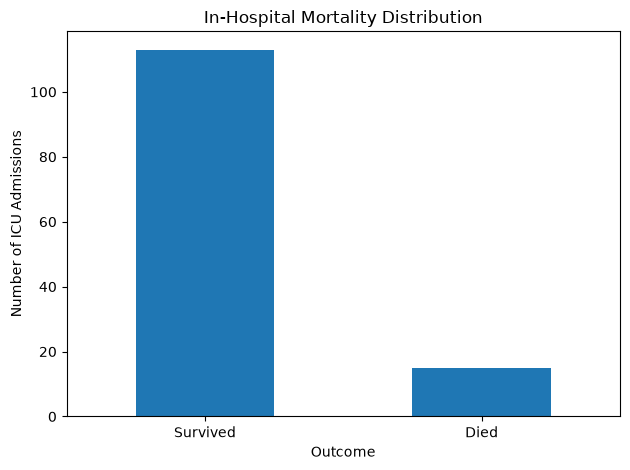

In [9]:
target_counts = (
    modeling_df["hospital_expire_flag"]
    .map({0: "Survived", 1: "Died"})
    .value_counts()
    .reindex(["Survived", "Died"])
)

ax = target_counts.plot(kind="bar")
ax.set_title("In-Hospital Mortality Distribution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of ICU Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Missingness analysis

In [10]:
missingness_summary = pd.DataFrame(
    {
        "missing_count": modeling_df.isna().sum(),
        "missing_percentage": (
            modeling_df.isna().mean() * 100
        ).round(2),
        "data_type": modeling_df.dtypes.astype(str),
    }
)

missingness_summary = missingness_summary.sort_values(
    "missing_percentage",
    ascending=False,
)

missingness_summary

,missing_count,missing_percentage,data_type
marital_status,10,7.81,str
hadm_id,0,0.00,int64
subject_id,0,0.00,int64
intime,0,0.00,str
prediction_time,0,0.00,str
outtime,0,0.00,str
stay_id,0,0.00,int64
gender,0,0.00,str
anchor_age,0,0.00,int64
admission_location,0,0.00,str


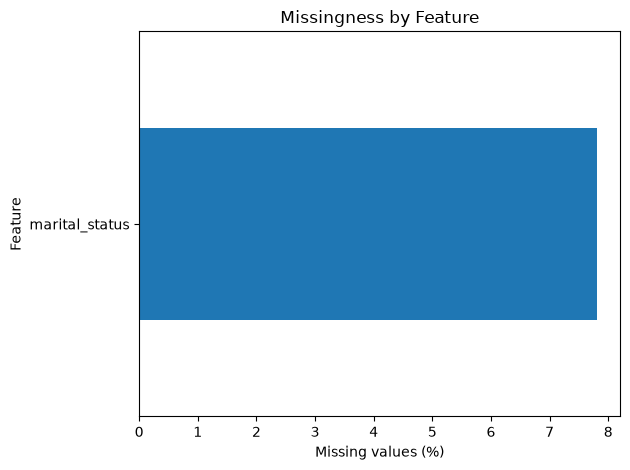

In [11]:
columns_with_missingness = missingness_summary.loc[
    missingness_summary["missing_count"] > 0
].copy()

if columns_with_missingness.empty:
    print("No missing values were found.")
else:
    ax = columns_with_missingness[
        "missing_percentage"
    ].sort_values().plot(kind="barh")

    ax.set_title("Missingness by Feature")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

### Missingness by outcome

This comparison is descriptive. Missingness can itself reflect clinical processes, but no missing-value treatment is selected here.

In [12]:
feature_columns = [
    column for column in modeling_df.columns
    if column not in [
        "subject_id",
        "hadm_id",
        "stay_id",
        "hospital_expire_flag",
    ]
]

missingness_by_outcome = (
    modeling_df
    .groupby("hospital_expire_flag")[feature_columns]
    .agg(lambda series: series.isna().mean() * 100)
    .T
    .rename(columns={0: "survivor_missing_pct", 1: "death_missing_pct"})
    .round(2)
)

missingness_by_outcome["absolute_difference_pct"] = (
    missingness_by_outcome["death_missing_pct"]
    - missingness_by_outcome["survivor_missing_pct"]
).abs().round(2)

missingness_by_outcome.sort_values(
    "absolute_difference_pct",
    ascending=False,
)

hospital_expire_flag,survivor_missing_pct,death_missing_pct,absolute_difference_pct
marital_status,7.96,6.67,1.29
prediction_time,0.00,0.00,0.00
intime,0.00,0.00,0.00
outtime,0.00,0.00,0.00
gender,0.00,0.00,0.00
admission_type,0.00,0.00,0.00
anchor_age,0.00,0.00,0.00
admission_location,0.00,0.00,0.00
insurance,0.00,0.00,0.00
race,0.00,0.00,0.00


## 6. Examine repeated patients

In [13]:
admissions_per_patient = (
    modeling_df.groupby("subject_id")["hadm_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Maximum admissions for one patient:", admissions_per_patient.max())
print(
    "Patients with more than one admission:",
    int((admissions_per_patient > 1).sum()),
)

admissions_per_patient.head(10)

Maximum admissions for one patient: 3
Patients with more than one admission: 21


subject_id
10002428    3
10014354    3
10016742    3
10015931    3
10023117    3
10019003    3
10039708    3
10020187    2
10005817    2
10003400    2
Name: hadm_id, dtype: int64

## 7. Create a patient-level stratification table

A patient can have multiple admissions. To prevent the same patient from appearing in multiple datasets, splitting is performed using `subject_id`.

For stratification, the patient-level outcome is set to 1 when the patient has at least one admission ending in in-hospital death.

In [14]:
patient_outcomes = (
    modeling_df
    .groupby("subject_id", as_index=False)
    .agg(
        patient_mortality=("hospital_expire_flag", "max"),
        number_of_admissions=("hadm_id", "nunique"),
    )
)

print("Patient-level table shape:", patient_outcomes.shape)
print()
print("Patient-level outcome distribution:")
print(patient_outcomes["patient_mortality"].value_counts())
print()
print("Patient-level outcome proportions:")
print(
    patient_outcomes["patient_mortality"]
    .value_counts(normalize=True)
    .sort_index()
)

patient_outcomes.head()

Patient-level table shape: (100, 3)

Patient-level outcome distribution:
patient_mortality
0    85
1    15
Name: count, dtype: int64

Patient-level outcome proportions:
patient_mortality
0    0.85
1    0.15
Name: proportion, dtype: float64


,subject_id,patient_mortality,number_of_admissions
0,10000032,0,1
1,10001217,0,2
2,10001725,0,1
3,10002428,0,3
4,10002495,0,1


## 8. Split patients into 70% training, 15% validation, and 15% test sets

In [15]:
def can_stratify(labels: pd.Series, number_of_splits: int = 2) -> bool:
    """Return True when every class has enough observations for a split."""
    class_counts = labels.value_counts()
    return (
        labels.nunique() > 1
        and class_counts.min() >= number_of_splits
    )


first_stratify = (
    patient_outcomes["patient_mortality"]
    if can_stratify(patient_outcomes["patient_mortality"])
    else None
)

if first_stratify is None:
    print(
        "Warning: The demo dataset does not contain enough patients "
        "in every outcome class for the first stratified split. "
        "Proceeding without stratification."
    )

train_patients, temporary_patients = train_test_split(
    patient_outcomes,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=first_stratify,
)

second_stratify = (
    temporary_patients["patient_mortality"]
    if can_stratify(temporary_patients["patient_mortality"])
    else None
)

if second_stratify is None:
    print(
        "Warning: The temporary demo subset does not contain enough "
        "patients in every outcome class for the second stratified split. "
        "Proceeding without stratification."
    )

validation_patients, test_patients = train_test_split(
    temporary_patients,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=second_stratify,
)

print("Training patients:", len(train_patients))
print("Validation patients:", len(validation_patients))
print("Test patients:", len(test_patients))

Training patients: 70
Validation patients: 15
Test patients: 15


## 9. Map patient assignments back to admission-level rows

In [16]:
train_subject_ids = set(train_patients["subject_id"])
validation_subject_ids = set(validation_patients["subject_id"])
test_subject_ids = set(test_patients["subject_id"])

train_df = modeling_df.loc[
    modeling_df["subject_id"].isin(train_subject_ids)
].copy()

validation_df = modeling_df.loc[
    modeling_df["subject_id"].isin(validation_subject_ids)
].copy()

test_df = modeling_df.loc[
    modeling_df["subject_id"].isin(test_subject_ids)
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Test rows:", len(test_df))

Training rows: 89
Validation rows: 20
Test rows: 19


## 10. Verify that no patient leakage exists

In [17]:
assert train_subject_ids.isdisjoint(validation_subject_ids), (
    "Patient overlap found between training and validation sets."
)

assert train_subject_ids.isdisjoint(test_subject_ids), (
    "Patient overlap found between training and test sets."
)

assert validation_subject_ids.isdisjoint(test_subject_ids), (
    "Patient overlap found between validation and test sets."
)

assert len(train_df) + len(validation_df) + len(test_df) == len(modeling_df), (
    "The split row counts do not add up to the original dataset."
)

assert set(train_df["subject_id"]) == train_subject_ids
assert set(validation_df["subject_id"]) == validation_subject_ids
assert set(test_df["subject_id"]) == test_subject_ids

print("Patient-level split validation passed.")
print("No subject_id appears in more than one split.")

Patient-level split validation passed.
No subject_id appears in more than one split.


## 11. Summarize the three datasets

In [18]:
def summarize_split(dataframe: pd.DataFrame, split_name: str) -> dict:
    return {
        "split": split_name,
        "rows": len(dataframe),
        "unique_patients": dataframe["subject_id"].nunique(),
        "unique_admissions": dataframe["hadm_id"].nunique(),
        "deaths": int(dataframe["hospital_expire_flag"].sum()),
        "survivors": int(
            (dataframe["hospital_expire_flag"] == 0).sum()
        ),
        "mortality_rate": round(
            dataframe["hospital_expire_flag"].mean(),
            4,
        ),
    }


split_summary = pd.DataFrame(
    [
        summarize_split(train_df, "train"),
        summarize_split(validation_df, "validation"),
        summarize_split(test_df, "test"),
    ]
)

split_summary

,split,rows,unique_patients,unique_admissions,deaths,survivors,mortality_rate
0,train,89,70,89,11,78,0.1236
1,validation,20,15,20,2,18,0.1000
2,test,19,15,19,2,17,0.1053


In [19]:
split_target_counts = pd.crosstab(
    pd.concat(
        [
            train_df.assign(split="train"),
            validation_df.assign(split="validation"),
            test_df.assign(split="test"),
        ],
        ignore_index=True,
    )["split"],
    pd.concat(
        [
            train_df.assign(split="train"),
            validation_df.assign(split="validation"),
            test_df.assign(split="test"),
        ],
        ignore_index=True,
    )["hospital_expire_flag"],
)

split_target_counts = split_target_counts.rename(
    columns={0: "survived", 1: "died"}
)

split_target_counts

hospital_expire_flag,survived,died
split,,
test,17,2
train,78,11
validation,18,2


## 12. Define future model columns

Identifiers are retained in the saved raw split files for validation and patient tracking. They will be removed from the predictor matrix before model training.

No imputation, scaling, or encoding is performed in this notebook.

In [20]:
identifier_columns = [
    "subject_id",
    "hadm_id",
    "stay_id",
]

target_column = "hospital_expire_flag"

predictor_columns = [
    column for column in modeling_df.columns
    if column not in identifier_columns + [target_column]
]

numeric_features = (
    modeling_df[predictor_columns]
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

categorical_features = (
    modeling_df[predictor_columns]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Identifier columns:", identifier_columns)
print("Target column:", target_column)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Identifier columns: ['subject_id', 'hadm_id', 'stay_id']
Target column: hospital_expire_flag
Numeric features: ['anchor_age']
Categorical features: ['intime', 'prediction_time', 'outtime', 'gender', 'admission_type', 'admission_location', 'insurance', 'marital_status', 'race', 'first_careunit']


C:\Users\yaooz\AppData\Local\Temp\ipykernel_37228\2645320085.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object", "category"])


## 13. Save raw splits and summary tables

In [21]:
train_output_path = PROCESSED_DIR / "train_cohort_raw.csv"
validation_output_path = PROCESSED_DIR / "validation_cohort_raw.csv"
test_output_path = PROCESSED_DIR / "test_cohort_raw.csv"

split_summary_path = RESULTS_DIR / "split_summary.csv"
missingness_summary_path = RESULTS_DIR / "missingness_summary.csv"
missingness_by_outcome_path = RESULTS_DIR / "missingness_by_outcome.csv"
target_summary_path = RESULTS_DIR / "target_summary.csv"

train_df.to_csv(train_output_path, index=False)
validation_df.to_csv(validation_output_path, index=False)
test_df.to_csv(test_output_path, index=False)

split_summary.to_csv(split_summary_path, index=False)
missingness_summary.to_csv(missingness_summary_path)
missingness_by_outcome.to_csv(missingness_by_outcome_path)
target_summary.to_csv(target_summary_path, index=False)

print("Saved:")
print("-", train_output_path)
print("-", validation_output_path)
print("-", test_output_path)
print("-", split_summary_path)
print("-", missingness_summary_path)
print("-", missingness_by_outcome_path)
print("-", target_summary_path)

Saved:
- ..\data\processed\train_cohort_raw.csv
- ..\data\processed\validation_cohort_raw.csv
- ..\data\processed\test_cohort_raw.csv
- ..\results\tables\split_summary.csv
- ..\results\tables\missingness_summary.csv
- ..\results\tables\missingness_by_outcome.csv
- ..\results\tables\target_summary.csv


## 14. Final validation of saved files

In [22]:
saved_paths = [
    train_output_path,
    validation_output_path,
    test_output_path,
    split_summary_path,
    missingness_summary_path,
    missingness_by_outcome_path,
    target_summary_path,
]

for path in saved_paths:
    assert path.exists(), f"Expected output file was not created: {path}"

saved_train = pd.read_csv(train_output_path)
saved_validation = pd.read_csv(validation_output_path)
saved_test = pd.read_csv(test_output_path)

assert set(saved_train["subject_id"]).isdisjoint(
    set(saved_validation["subject_id"])
)
assert set(saved_train["subject_id"]).isdisjoint(
    set(saved_test["subject_id"])
)
assert set(saved_validation["subject_id"]).isdisjoint(
    set(saved_test["subject_id"])
)

print("All files were saved successfully.")
print("Saved patient-level split validation passed.")

All files were saved successfully.
Saved patient-level split validation passed.


## Notebook 3 Summary

- Loaded and validated the admission-level ICU mortality cohort.
- Examined the outcome distribution and missing data.
- Confirmed that some patients can contribute multiple admissions.
- Split the cohort by `subject_id` into training, validation, and test sets.
- Verified that no patient appears in more than one set.
- Preserved raw features without fitting preprocessing on validation or test data.
- Saved raw datasets for later feature engineering and modeling.

### Next step

Update Notebook 2 to retain ICU `intime`, then create Notebook 4 to engineer admission-time features and extract first-24-hour vital signs.